In [1]:
import json

import brian2
from brian2 import ms, mV, nF, nS, Hz
import matplotlib.pyplot as plt

import load_models
brian2.defaultclock.dt = 0.001*ms

In [2]:
with open('neuron_model.txt', 'r') as model_f, open('neuron_parameters_original.json', 'r') as params_f:
    neurongroup_dict = load_models.load_neurongroups(
        model_f.read(),
        json.load(params_f)
    )
for neurongroup in neurongroup_dict.values():
    neurongroup.v = -70*mV

with open('synapse_models.json', 'r') as model_f, open('synapse_parameters.json', 'r') as params_f:
    synapse_dict = load_models.load_synapses(
        neurongroup_dict,
        json.load(model_f),
        json.load(params_f)
    )

P = brian2.PoissonGroup(800, 100*Hz)
C_P = brian2.Synapses(
    P, neurongroup_dict['Pyramidal_Cells'],
    on_pre="""
    g_AMPA_r += w
    g_AMPA_d += w
    g_NMDA_r += w
    g_NMDA_d += w
    """,
    namespace=dict(w=16*nS)
)
C_P.connect('i==j')

In [3]:
spikemonitors = [brian2.SpikeMonitor(neurongroup) for neurongroup in neurongroup_dict.values()]
rec = [0, 1, 2]
vmonitors = [brian2.StateMonitor(neurongroup, 'v', record=rec) for neurongroup in neurongroup_dict.values()]
gmonitors = [brian2.StateMonitor(neurongroup, ['g_AMPA', 'g_NMDA', 'g_GABA'], record=rec) for neurongroup in neurongroup_dict.values()]
grmonitors = [brian2.StateMonitor(neurongroup, ['g_AMPA_r', 'g_NMDA_r', 'g_GABA_r'], record=rec) for neurongroup in neurongroup_dict.values()]
gdmonitors = [brian2.StateMonitor(neurongroup, ['g_AMPA_d', 'g_NMDA_d', 'g_GABA_d'], record=rec) for neurongroup in neurongroup_dict.values()]
Imonitors = [brian2.StateMonitor(neurongroup, ['I_syn', 'I_AMPA', 'I_NMDA', 'I_GABA'], record=rec) for neurongroup in neurongroup_dict.values()]
Pmonitor = brian2.SpikeMonitor(P)

net = brian2.Network()
net.add(neurongroup_dict.values())
net.add(synapse_dict)
net.add(spikemonitors)
net.add([vmonitors, gmonitors, Imonitors, Pmonitor])
net.add([P, C_P])
net.get_states()

70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70.]) * mvolt,
  'v': array([-70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70., -70., -70.,
         -70., -70., -70., -70., -70., -70., -70., -70., -70.,

In [4]:
net.run(100*ms)

INFO       No numerical integration method specified for group 'Fast_Spiking_Interneurons', using method 'euler' (took 0.03s, trying other methods took 0.42s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'Pyramidal_Cells', using method 'euler' (took 0.01s, trying other methods took 0.25s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'Regular_Spiking_Interneurons', using method 'euler' (took 0.01s, trying other methods took 0.24s). [brian2.stateupdaters.base.method_choice]


WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


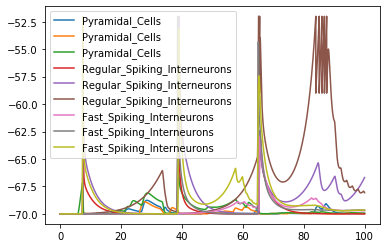

In [5]:
for monitor in vmonitors:
    plt.plot(monitor.t/ms, (monitor.v/mV).T, label=monitor.source.name)
plt.legend()

WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


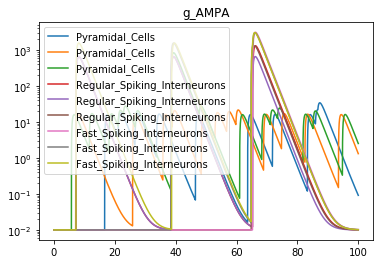

WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


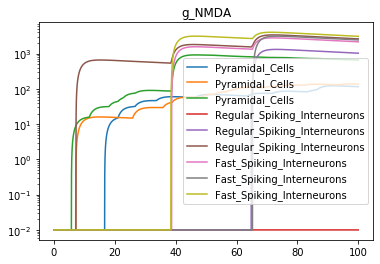

WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


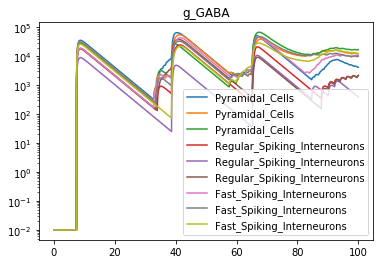

In [6]:
for gname in gmonitors[0].record_variables:
    for monitor in gmonitors:
        plt.plot(monitor.t/ms, (getattr(monitor, gname)/nS).T+1e-2, label=monitor.source.name)
    plt.title(gname)
    plt.legend()
    plt.yscale('log')
    plt.show()

WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


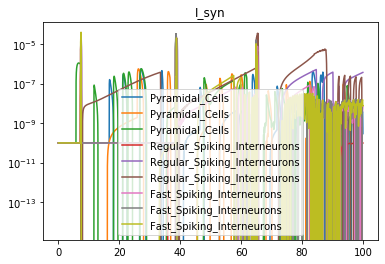

WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


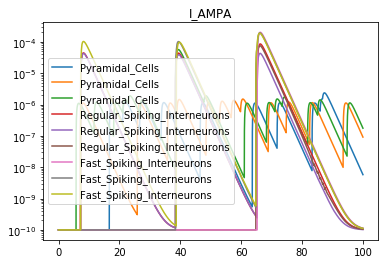

WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


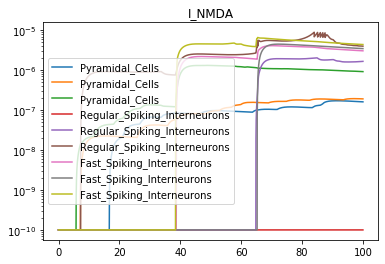

WARNING    /home/yi/.local/lib/python3.6/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]


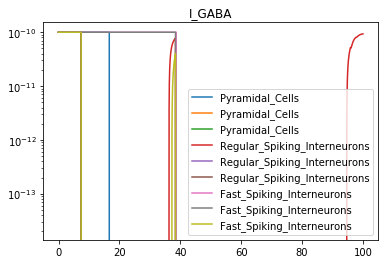

In [7]:
for Iname in Imonitors[0].record_variables:
    for monitor in Imonitors:
        plt.plot(monitor.t/ms, (getattr(monitor, Iname)/brian2.mA).T+1e-10, label=monitor.source.name)
    plt.title(Iname)
    plt.yscale('log')
    plt.legend()
    plt.show()

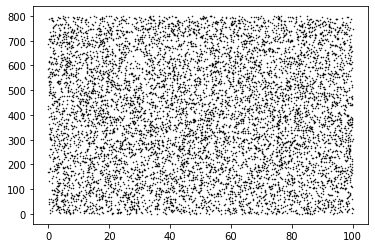

In [8]:
plt.plot(Pmonitor.t/ms, Pmonitor.i, '.k', markersize=1)

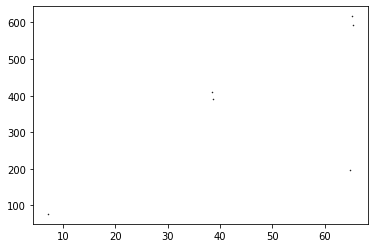

In [9]:
plt.plot(spikemonitors[0].t/ms, spikemonitors[0].i, '.k', markersize=1)